In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.table import Table
from collections import Counter

catalog_dir = "/home/alab_student/Tim/Projects/MeV_Blazars/Data"
outdir = '/home/alab_student/Tim/Projects/MeV_Blazars/Outputs'

In [18]:
def mask_catalog_by_class(catalog, class_column):
    fsrq_mask = [x in ['FSRQ','fsrq'] for x in catalog[class_column].tolist()]
    bll_mask = [x in ['BLL','bll'] for x in catalog[class_column].tolist()]
    bcu_mask = [x in ['BCU','bcu'] for x in catalog[class_column].tolist()]

    fsrq_masked_catalog = catalog[fsrq_mask]
    bll_masked_catalog = catalog[bll_mask]
    bcu_masked_catalog = catalog[bcu_mask]

    return fsrq_masked_catalog, bll_masked_catalog, bcu_masked_catalog

In [19]:
MeV_Blazar_Catalog_SED_Fits = Table.read(catalog_dir + "MeV_Blazar_Catalog_v2_SED_Fits.fits")

FSRQ, BLL, BCU = mask_catalog_by_class(MeV_Blazar_Catalog_SED_Fits, 'Fermi_Type')
MeV_Blazars = [FSRQ, BLL, BCU]


colors=['blue','red','purple']
labels=['FSRQ','BLL','BCU']

In [ ]:
# Swift, Fermi, and synchrotron peak classification distributions

print(Counter([x.upper() for x in MeV_Blazar_Catalog_SED_Fits['Fermi_Type'].tolist()]))
print(Counter(MeV_Blazar_Catalog_SED_Fits['Swift_Type'].tolist()))
print(Counter(MeV_Blazar_Catalog_SED_Fits['SED_Class'].tolist()))

Counter({'FSRQ': 61, 'BLL': 43, 'BCU': 11})
Counter({'BZQ': 44, 'Beamed AGN': 32, 'BZB': 22, 'FSRQ': 10, 'BZG': 6, 'BZQ/Lense': 1})
Counter({'LSP': 69, 'HSP': 38, 'None': 6, 'ISP': 2})


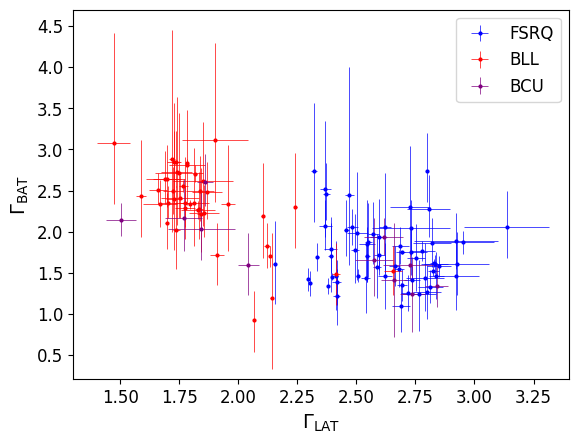

In [ ]:
# Distribution of hard X-ray and GeV gamma-ray indexes (informs fitting).

for i in range(len(MeV_Blazars)):
    BAT_index = MeV_Blazars[i]['Swift_Photon_Index'].tolist()
    BAT_index_err = MeV_Blazars[i]['Swift_Photon_Index_Err'].tolist()
    
    BAT_index_errors = [[],[]]
    
    for x in range(len(BAT_index_err)):
        err_lo = BAT_index[x] - BAT_index_err[x][0]
        err_hi = BAT_index_err[x][1] - BAT_index[x] 
        BAT_index_errors[0].append(err_lo)
        BAT_index_errors[1].append(err_hi)
        
    Fermi_index = MeV_Blazars[i]['Fermi_Photon_Index'].tolist()
    Fermi_index_err = [0 if x == 'None' else float(x) for x in MeV_Blazars[i]['Fermi_Photon_Index_Err'].tolist()]
    
    plt.errorbar(Fermi_index, BAT_index, yerr=BAT_index_errors, xerr=Fermi_index_err, fmt='o',markersize=2,elinewidth=0.5,color=colors[i],label=labels[i])
    plt.xlabel(r'$\Gamma_{\mathrm{LAT}}$', fontsize=14)
    plt.ylabel(r'$\Gamma_{\mathrm{BAT}}$', fontsize=14)

#plt.plot(np.linspace(1,3.5,100),np.linspace(1,3.5,100),color='grey',linestyle='--',label='x=y')
plt.xlim(1.3,3.4)
plt.ylim(0.2,4.7)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', labelsize=12)

plt.savefig(outdir + '/LAT_BAT_index_comparison.pdf', dpi=300,bbox_inches='tight')
        

57
34
3


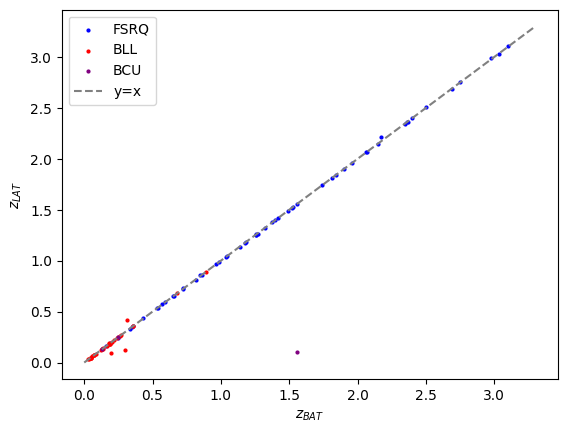

In [ ]:
# Compare Swift and Fermi Redshifts for matching validation.

for i in range(len(MeV_Blazars)):
    Swift_Redshift = MeV_Blazars[i]['Swift_Redshift'].tolist()
    Fermi_Redshift = MeV_Blazars[i]['Fermi_Redshift'].tolist()
    
    Swift_Redshift_Masked = [float(Swift_Redshift[x]) for x in range(len(Swift_Redshift)) if Swift_Redshift[x] != 'None' and Fermi_Redshift[x] != 'None']
    Fermi_Redshift_Masked = [float(Fermi_Redshift[x]) for x in range(len(Swift_Redshift)) if Swift_Redshift[x] != 'None' and Fermi_Redshift[x] != 'None']
    print(len(Swift_Redshift_Masked))
    plt.scatter(Swift_Redshift_Masked, Fermi_Redshift_Masked, s=4,label=labels[i],color=colors[i])
    plt.xlabel(r'$z_{BAT}$')
    plt.ylabel(r'$z_{LAT}$')
    
plt.plot(np.linspace(0,3.3,100),np.linspace(0,3.3,100),linestyle='--',label='y=x',color='grey')
plt.legend(loc='upper left')